In [59]:
import os
from pathlib import Path
import pandas as pd

In [60]:
dataset_dir = Path("./Datasets")

In [61]:
mnist_dir = dataset_dir / "MNIST"
vww_dir = dataset_dir / "visual_wake_words"

In [62]:
def visualize_dataset(dataset_dir):
    result = {}
    for section in dataset_dir.iterdir():
        if section.is_dir():
            result[section.name] = {}
            for x_class in section.iterdir():
                classes = result[section.name]
                if x_class.is_dir():
                    classes[x_class.name] = 0
                    for img_file in x_class.iterdir():
                        if (img_file.suffix).lower() in [".png", ".jpg", ".jpeg"]:
                            classes[x_class.name]+=1
                        else:
                            print(img_file.name)
                            print(img_file.suffix)
                            raise Exception("ควย")
                            
    return result
                            
                

In [63]:
test_dir = dataset_dir / "MelanomaSkinCancer"
test = visualize_dataset(test_dir)
df_test = pd.DataFrame(test)
df_test = df_test.transpose()
df_test.sum().sum()

np.int64(10605)

In [64]:
minist = visualize_dataset(mnist_dir)
df_mnist = pd.DataFrame(minist)
df_mnist = df_mnist.transpose()
df_mnist.sum().sum()

np.int64(70000)

In [65]:
vww = visualize_dataset(vww_dir)
df_vww = pd.DataFrame(vww)
df_vww = df_vww.transpose()
df_vww.sum().sum()

np.int64(123287)

In [66]:
(70000/50) * 5

7000.0

In [67]:
def get_data(dataset_dir):
    data = []
    for section in dataset_dir.iterdir():
        if section.is_dir():
            for x_class in section.iterdir():
                if x_class.is_dir():
                    for img_file in x_class.iterdir():
                        if (img_file.suffix).lower() in [".png", ".jpg", ".jpeg"]:
                            row = [section.name, 
                                   x_class.name,
                                   dataset_dir / section.name / x_class.name / img_file.name,
                                   img_file.name]
                            data.append(row)
                            
                            
    return data
                            
                

In [68]:
column_name = ["section", "class", "path", "file"]

In [ ]:
minist = get_data(mnist_dir)
df_mnist = pd.DataFrame(minist)
df_mnist.columns = column_name
print(df_mnist.shape[0])
df_mnist.sample(10)

In [70]:
7000/df_mnist.shape[0]

0.1

In [ ]:
vww = get_data(vww_dir)
df_vww = pd.DataFrame(vww)
df_vww.columns = column_name
print(df_vww.shape[0])
df_vww.sample(10)

In [72]:
7000/df_vww.shape[0]

0.05677808690291758

In [83]:
from sklearn.model_selection import train_test_split
import os

# 1. Define how much data you want to KEEP (e.g., 0.7 for 70%)
keep_ratio = 0.05677808690291758

# 2. Perform the stratified split
# 'stratify=df["class"]' ensures the digit distribution remains the same
df_keep, df_delete = train_test_split(
    df_vww, 
    test_size=(1 - keep_ratio),
    stratify=df_vww[['section', 'class']],
    random_state=42 # For reproducibility
)



In [85]:
len(df_vww[df_vww["section"] == "test"]) / len(df_vww[df_vww["section"] == "train"])

0.06993959801437151

In [86]:
len(df_keep[df_keep["section"] == "test"]) / len(df_keep[df_keep["section"] == "train"])

0.07000917150718435

In [88]:
df_keep.shape[0]

7000

<Axes: xlabel='class'>

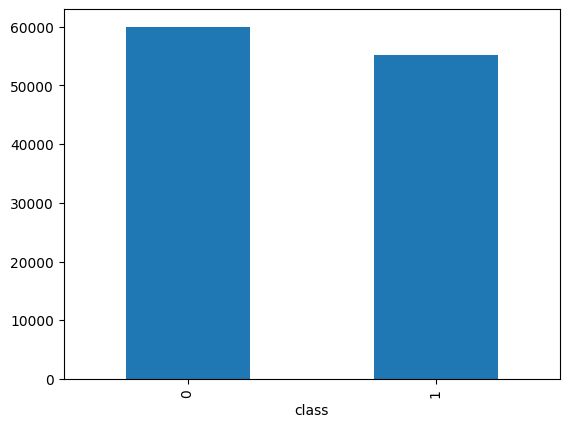

In [89]:
df_vww[df_vww["section"] == "train"].value_counts("class").sort_index().plot.bar()

<Axes: xlabel='class'>

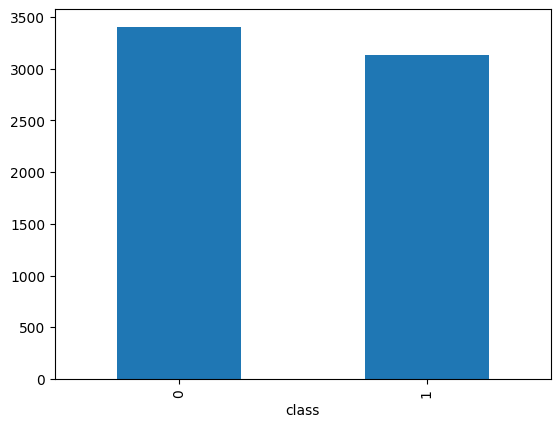

In [91]:
df_keep[df_keep["section"] == "train"].value_counts("class").sort_index().plot.bar()

## +++++++++++++++++++

<Axes: xlabel='class'>

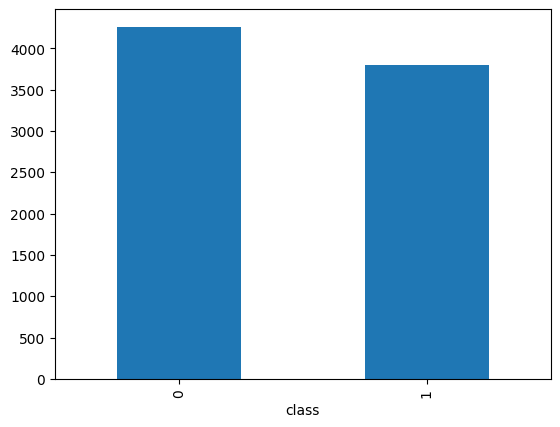

In [92]:
df_vww[df_vww["section"] == "test"].value_counts("class").sort_index().plot.bar()

<Axes: xlabel='class'>

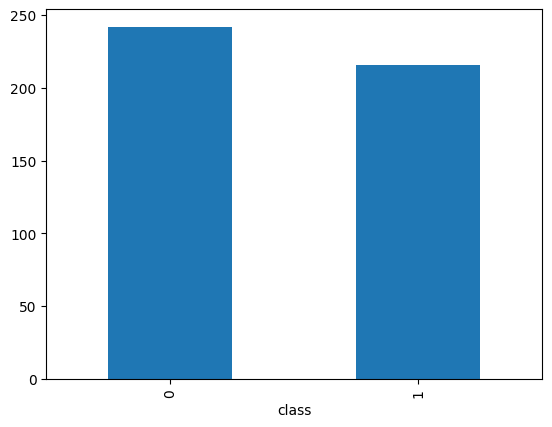

In [93]:
df_keep[df_keep["section"] == "test"].value_counts("class").sort_index().plot.bar()

In [94]:
print(f"Files to be deleted: {len(df_delete)}")

# 3. Delete the files from the disk
def delete_files(path_list):
    count = 0
    for file_path in path_list:
        try:
            # Since it's a pathlib object, use .unlink()
            file_path.unlink(missing_ok=True) 
            count += 1
        except Exception as e:
            print(f"Error deleting {file_path}: {e}")
    return count

# Execute deletion
deleted_count = delete_files(df_delete['path'])
print(f"Successfully deleted {deleted_count} files.")

Files to be deleted: 116287
Successfully deleted 116287 files.
